# 一、載入套件及資料集

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import platform
import os

def setup_chinese_font():
    """設定 matplotlib 中文字體顯示"""
    system = platform.system()
    
    if system == 'Windows':  # Windows 系統
        font_candidates = [ 'Microsoft YaHei', 'SimHei', 'Arial Unicode MS' ]
    elif system == 'Darwin':  # macOS
        font_candidates = [ 'Arial Unicode MS', 'Heiti TC', 'STHeiti' ]
    else:  # Linux
        font_candidates = [ 'Noto Sans CJK JP' ]
    
    # 測試字體是否可用
    import matplotlib.font_manager as fm
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in font_candidates:
        if font in available_fonts:
            plt.rcParams['font.sans-serif'] = [font]
            # print(f"✅ 使用字體: {font}")
            break
    else:
        # print("⚠️  未找到合適的中文字體，使用預設字體")
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    
    # 解決負號顯示問題
    plt.rcParams['axes.unicode_minus'] = False
    
    # # 設定字體大小和樣式
    # plt.rcParams['font.size'] = 10
    # plt.rcParams['axes.titlesize'] = 12
    # plt.rcParams['axes.labelsize'] = 11
    # plt.rcParams['xtick.labelsize'] = 9
    # plt.rcParams['ytick.labelsize'] = 9
    # plt.rcParams['legend.fontsize'] = 9

# 設定中文字體
setup_chinese_font()

# === 讀取資料 ===
rawData = pd.read_csv('../Urban_Air_Quality_and_Health_Impact_Dataset.csv')
rawData.info()
rawData.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           1000 non-null   object 
 1   datetimeEpoch      1000 non-null   float64
 2   tempmax            1000 non-null   float64
 3   tempmin            1000 non-null   float64
 4   temp               1000 non-null   float64
 5   feelslikemax       1000 non-null   float64
 6   feelslikemin       1000 non-null   float64
 7   feelslike          1000 non-null   float64
 8   dew                1000 non-null   float64
 9   humidity           1000 non-null   float64
 10  precip             1000 non-null   float64
 11  precipprob         1000 non-null   float64
 12  precipcover        1000 non-null   float64
 13  preciptype         378 non-null    object 
 14  snow               1000 non-null   float64
 15  snowdepth          929 non-null    float64
 16  windgust           1000 n

(1000, 46)

# 缺失值處理

📊 資料集基本資訊
資料筆數: 1,000
欄位數量: 46
資料大小: 0.90 MB

🔍 缺失值分析

⚠️  發現 4 個欄位有缺失值：

          欄位名稱  缺失數量  缺失比例(%)    資料型別
      stations   933     93.3  object
    preciptype   622     62.2  object
Condition_Code   431     43.1 float64
     snowdepth    71      7.1 float64

--------------------------------------------------------------------------------
📈 缺失值統計摘要：
   • 總缺失值數量: 2,057
   • 平均缺失比例: 51.42%
   • 最高缺失比例: 93.30% (stations)

--------------------------------------------------------------------------------
🎯 缺失值嚴重程度分類：

   🔴 嚴重缺失 (>50%): 2 個欄位
      → stations, preciptype
      建議: 考慮刪除這些欄位或僅作為參考

   🟡 中度缺失 (10-50%): 1 個欄位
      → Condition_Code
      建議: 謹慎處理，可考慮插補或標記缺失

   🟢 輕微缺失 (<10%): 1 個欄位
      → snowdepth
      建議: 可用均值/中位數/眾數插補

📋 完整欄位列表及資料型別：
             欄位名稱    資料型別  缺失數量
         datetime  object     0
    datetimeEpoch float64     0
          tempmax float64     0
          tempmin float64     0
             temp float64     0
     feelslikemax float64     0
     feelslikemi

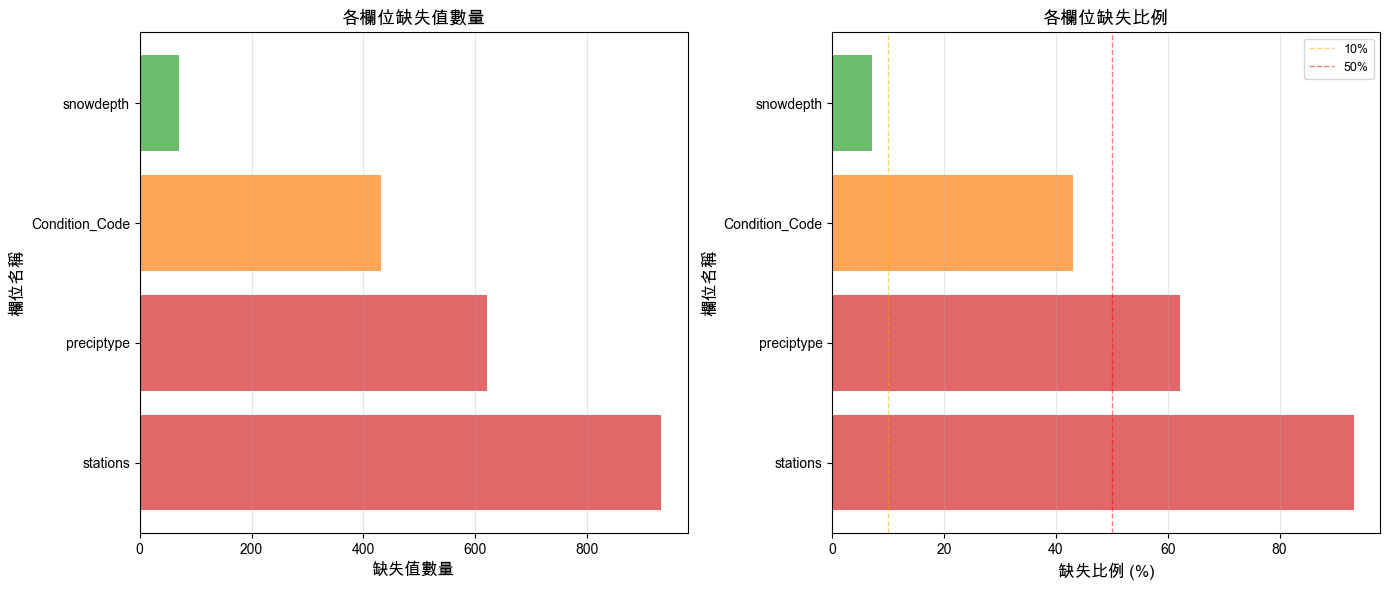


💡 缺失值處理建議：
1. 刪除欄位: 缺失比例 > 50% 的欄位，資訊價值較低
2. 刪除列: 若某些觀測值缺失過多欄位，可考慮刪除該列
3. 數值型插補: 使用均值(mean)、中位數(median)或前後值插補
4. 類別型插補: 使用眾數(mode)或新增'Unknown'類別
5. 進階方法: KNN插補、迴歸插補、多重插補(MICE)
6. 標記缺失: 新增二元欄位標記是否為缺失值，保留缺失模式資訊


In [27]:
# 缺失值分析與統計
print("=" * 80)
print("📊 資料集基本資訊")
print("=" * 80)
print(f"資料筆數: {rawData.shape[0]:,}")
print(f"欄位數量: {rawData.shape[1]}")
print(f"資料大小: {rawData.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 80)
print("🔍 缺失值分析")
print("=" * 80)

# 計算每個欄位的缺失值
missing_stats = pd.DataFrame({
    '欄位名稱': rawData.columns,
    '缺失數量': rawData.isnull().sum().values,
    '缺失比例(%)': (rawData.isnull().sum().values / len(rawData) * 100).round(2),
    '資料型別': rawData.dtypes.values
})

# 只顯示有缺失值的欄位
missing_data = missing_stats[missing_stats['缺失數量'] > 0].sort_values('缺失數量', ascending=False)

if len(missing_data) > 0:
    print(f"\n⚠️  發現 {len(missing_data)} 個欄位有缺失值：\n")
    print(missing_data.to_string(index=False))
    
    print("\n" + "-" * 80)
    print("📈 缺失值統計摘要：")
    print(f"   • 總缺失值數量: {missing_data['缺失數量'].sum():,}")
    print(f"   • 平均缺失比例: {missing_data['缺失比例(%)'].mean():.2f}%")
    print(f"   • 最高缺失比例: {missing_data['缺失比例(%)'].max():.2f}% ({missing_data.iloc[0]['欄位名稱']})")
    
    # 缺失值嚴重程度分類
    severe = missing_data[missing_data['缺失比例(%)'] > 50]
    moderate = missing_data[(missing_data['缺失比例(%)'] > 10) & (missing_data['缺失比例(%)'] <= 50)]
    minor = missing_data[missing_data['缺失比例(%)'] <= 10]
    
    print("\n" + "-" * 80)
    print("🎯 缺失值嚴重程度分類：")
    if len(severe) > 0:
        print(f"\n   🔴 嚴重缺失 (>50%): {len(severe)} 個欄位")
        print(f"      → {', '.join(severe['欄位名稱'].tolist())}")
        print(f"      建議: 考慮刪除這些欄位或僅作為參考")
    
    if len(moderate) > 0:
        print(f"\n   🟡 中度缺失 (10-50%): {len(moderate)} 個欄位")
        print(f"      → {', '.join(moderate['欄位名稱'].tolist())}")
        print(f"      建議: 謹慎處理，可考慮插補或標記缺失")
    
    if len(minor) > 0:
        print(f"\n   🟢 輕微缺失 (<10%): {len(minor)} 個欄位")
        print(f"      → {', '.join(minor['欄位名稱'].tolist())}")
        print(f"      建議: 可用均值/中位數/眾數插補")
    
else:
    print("\n✅ 太好了！資料集中沒有任何缺失值。")

# 顯示完整欄位列表
print("\n" + "=" * 80)
print("📋 完整欄位列表及資料型別：")
print("=" * 80)
print(missing_stats[['欄位名稱', '資料型別', '缺失數量']].to_string(index=False))

# 視覺化缺失值分佈
if len(missing_data) > 0:
    
    
    plt.figure(figsize=(14, 6))
    
    # 子圖1: 缺失值數量長條圖
    plt.subplot(1, 2, 1)
    colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 10 else '#2ca02c' 
              for x in missing_data['缺失比例(%)']]
    plt.barh(missing_data['欄位名稱'], missing_data['缺失數量'], color=colors, alpha=0.7)
    plt.xlabel('缺失值數量', fontsize=12)
    plt.ylabel('欄位名稱', fontsize=12)
    plt.title('各欄位缺失值數量', fontsize=13, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # 子圖2: 缺失比例百分比
    plt.subplot(1, 2, 2)
    plt.barh(missing_data['欄位名稱'], missing_data['缺失比例(%)'], color=colors, alpha=0.7)
    plt.xlabel('缺失比例 (%)', fontsize=12)
    plt.ylabel('欄位名稱', fontsize=12)
    plt.title('各欄位缺失比例', fontsize=13, fontweight='bold')
    plt.axvline(x=10, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='10%')
    plt.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50%')
    plt.legend(fontsize=9)
    plt.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 80)
    print("💡 缺失值處理建議：")
    print("=" * 80)
    print("1. 刪除欄位: 缺失比例 > 50% 的欄位，資訊價值較低")
    print("2. 刪除列: 若某些觀測值缺失過多欄位，可考慮刪除該列")
    print("3. 數值型插補: 使用均值(mean)、中位數(median)或前後值插補")
    print("4. 類別型插補: 使用眾數(mode)或新增'Unknown'類別")
    print("5. 進階方法: KNN插補、迴歸插補、多重插補(MICE)")
    print("6. 標記缺失: 新增二元欄位標記是否為缺失值，保留缺失模式資訊")
else:
    print("\n✨ 資料品質優良，可直接進行後續分析！")

In [28]:
# 缺失值處理 - 刪除無用的缺失值欄位

# 確認要刪除的欄位
columns_to_drop = ['stations', 'preciptype', 'Condition_Code', 'snowdepth']

print("=" * 80)
print("🗑️  刪除無用的缺失值欄位")
print("=" * 80)

# 顯示刪除前的資料形狀
print(f"\n刪除前:")
print(f"   • 資料筆數: {rawData.shape[0]:,}")
print(f"   • 欄位數量: {rawData.shape[1]}")

# 檢查欄位是否存在並顯示資訊
print(f"\n準備刪除的欄位:")
for col in columns_to_drop:
    if col in rawData.columns:
        missing_count = rawData[col].isna().sum()
        missing_pct = (missing_count / len(rawData) * 100)
        print(f"   ✓ {col:<20} - 缺失值: {missing_count:,} ({missing_pct:.2f}%)")
    else:
        print(f"   ✗ {col:<20} - 欄位不存在")

# 刪除欄位
existing_columns = [col for col in columns_to_drop if col in rawData.columns]
rawData = rawData.drop(columns=existing_columns)

print(f"\n刪除後:")
print(f"   • 資料筆數: {rawData.shape[0]:,}")
print(f"   • 欄位數量: {rawData.shape[1]}")
print(f"   • 已刪除欄位數: {len(existing_columns)}")

# 確認是否還有其他缺失值
remaining_missing = rawData.isnull().sum().sum()
if remaining_missing > 0:
    print(f"\n⚠️  資料集中仍有 {remaining_missing:,} 個缺失值需要處理")
    missing_cols = rawData.columns[rawData.isnull().any()].tolist()
    print(f"   有缺失值的欄位: {', '.join(missing_cols)}")
else:
    print(f"\n✅ 資料集中已無任何缺失值！")

print("\n" + "=" * 80)



🗑️  刪除無用的缺失值欄位

刪除前:
   • 資料筆數: 1,000
   • 欄位數量: 46

準備刪除的欄位:
   ✓ stations             - 缺失值: 933 (93.30%)
   ✓ preciptype           - 缺失值: 622 (62.20%)
   ✓ Condition_Code       - 缺失值: 431 (43.10%)
   ✓ snowdepth            - 缺失值: 71 (7.10%)

刪除後:
   • 資料筆數: 1,000
   • 欄位數量: 42
   • 已刪除欄位數: 4

✅ 資料集中已無任何缺失值！



# 資料清洗

# 資料轉換

label encoding / one hot encoding